In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

In [ ]:
countries = ["ethiopia", "kenya", "sudan", "tanzania", "nigeria"]
dfs = []
for country in countries:
    df = pd.read_csv(f"../data/{country}_clean.csv")
    df["Country"] = country.capitalize()
    #to make sure date is pared correctly
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
    dfs.append(df)
combined_df = pd.concat(dfs, ignore_index=True)
combined_df.shape
combined_df.head()
combined_df["Country"].value_counts()

(20535, 15)
   YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  \
0  2015    2  12.30    24.01     4.09      19.92          0.0  33.29  2.39   
1  2015    3  12.49    24.17     3.97      20.20          0.0  33.83  1.77   
2  2015    4  14.08    23.78     6.90      16.88          0.0  38.84  0.87   
3  2015    5  14.06    23.15     7.32      15.83          0.0  47.07  1.34   
4  2015    6  14.26    23.45     7.44      16.01          0.0  58.20  1.70   

   WS2M_MAX     PS  QV2M   Country       Date  MONTH  
0      4.19  77.14  3.35  Ethiopia 2015-01-02      1  
1      2.76  77.11  3.43  Ethiopia 2015-01-03      1  
2      1.28  77.07  4.60  Ethiopia 2015-01-04      1  
3      2.14  77.01  5.58  Ethiopia 2015-01-05      1  
4      2.75  77.07  6.95  Ethiopia 2015-01-06      1  
Country
Ethiopia    4107
Kenya       4107
Sudan       4107
Tanzania    4107
Nigeria     4107
Name: count, dtype: int64


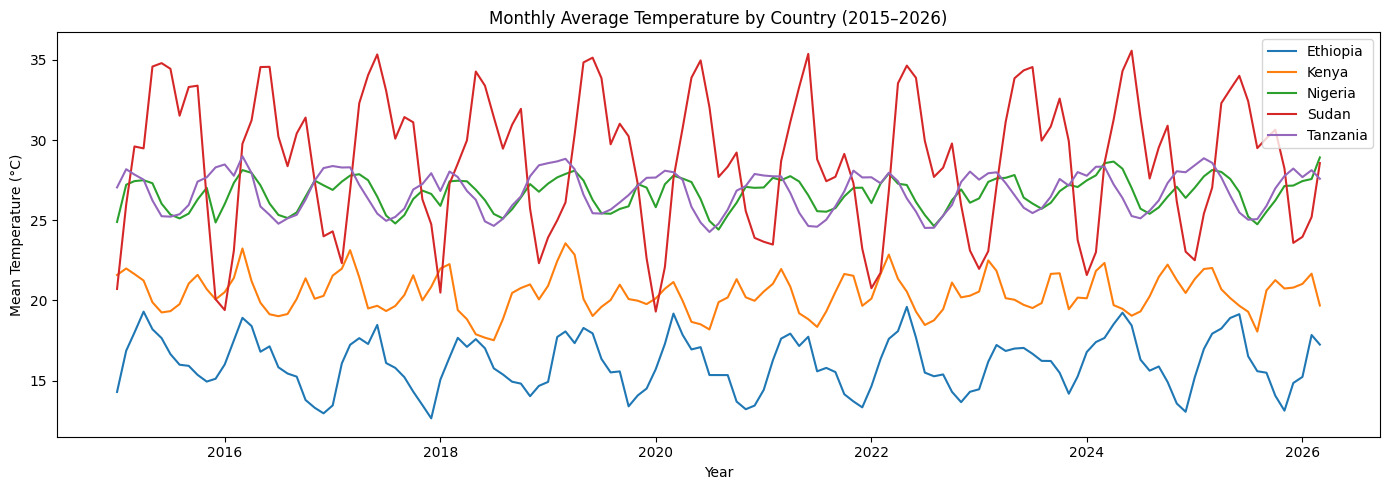

,mean,median,std
Country,,,
Ethiopia,16.07,16.04,1.90
Kenya,20.43,20.36,1.44
Nigeria,26.66,26.82,1.12
Sudan,28.76,29.16,4.68
Tanzania,26.80,26.99,1.33


In [9]:
# Monthly average T2M per country ─────────────────────────────────────────
monthly = (
    combined_df
    .groupby(["Country", "YEAR", "MONTH"])["T2M"]
    .mean()
    .reset_index()
)
monthly["Date"] = pd.to_datetime(
    monthly["YEAR"].astype(str) + "-" + monthly["MONTH"].astype(str)
)

fig, ax = plt.subplots(figsize=(14, 5))
for country, grp in monthly.groupby("Country"):
    ax.plot(grp["Date"], grp["T2M"], label=country, linewidth=1.5)

ax.set_title("Monthly Average Temperature by Country (2015–2026)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Temperature (°C)")
ax.legend()
plt.tight_layout()
plt.show()

# Summary table ──────────────────────────────────────────────────────────── 
temp_summary = (
    combined_df
    .groupby("Country")["T2M"]
    .agg(mean="mean", median="median", std="std")
    .round(2)
)
temp_summary

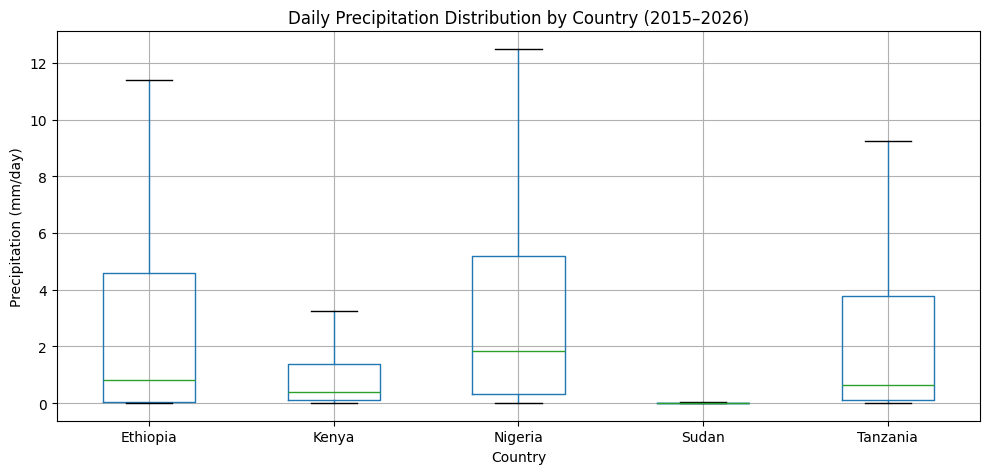

,mean,median,std
Country,,,
Ethiopia,3.635,0.82,6.290
Kenya,1.469,0.38,3.181
Nigeria,4.215,1.84,7.267
Sudan,0.644,0.00,3.058
Tanzania,3.739,0.64,8.005


In [10]:
# Side-by-side boxplots of daily precipitation ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
order = combined_df.groupby("Country")["PRECTOTCORR"].median().sort_values().index
combined_df.boxplot(
    column="PRECTOTCORR",
    by="Country",
    ax=ax,
    notch=False,
    showfliers=False,   # hide extreme points for readability
)
ax.set_title("Daily Precipitation Distribution by Country (2015–2026)")
ax.set_xlabel("Country")
ax.set_ylabel("Precipitation (mm/day)")
plt.suptitle("")       # suppress the auto-generated title from boxplot()
plt.tight_layout()
plt.show()

# Summary table ───────────────────────────────────────────────────────────
precip_summary = (
    combined_df
    .groupby("Country")["PRECTOTCORR"]
    .agg(mean="mean", median="median", std="std")
    .round(3)
)
precip_summary

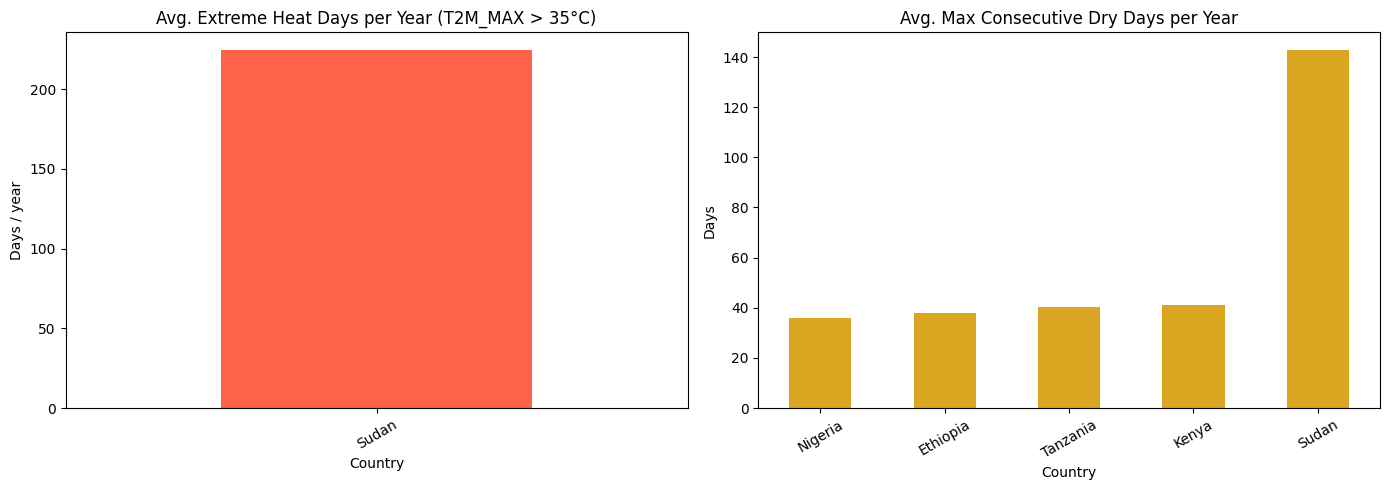

In [11]:
# ── Extreme heat days: T2M_MAX > 35°C ────────────────────────────────────
heat_days = (
    combined_df[combined_df["T2M_MAX"] > 35]
    .groupby(["Country", "YEAR"])
    .size()
    .reset_index(name="extreme_heat_days")
)
heat_summary = heat_days.groupby("Country")["extreme_heat_days"].mean().round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

heat_summary.sort_values().plot(kind="bar", ax=axes[0], color="tomato")
axes[0].set_title("Avg. Extreme Heat Days per Year (T2M_MAX > 35°C)")
axes[0].set_ylabel("Days / year")
axes[0].set_xlabel("Country")
axes[0].tick_params(axis="x", rotation=30)

# ── Consecutive dry days per year: PRECTOTCORR < 1 mm ────────────────────
def max_consecutive_dry(series):
    """Return max run of consecutive days where precip < 1 mm."""
    is_dry = (series < 1).astype(int)
    max_run = 0
    run = 0
    for v in is_dry:
        if v:
            run += 1
            max_run = max(max_run, run)
        else:
            run = 0
    return max_run

dry_runs = (
    combined_df
    .sort_values(["Country", "Date"])
    .groupby(["Country", "YEAR"])["PRECTOTCORR"]
    .apply(max_consecutive_dry)
    .reset_index(name="max_dry_run")
)
dry_summary = dry_runs.groupby("Country")["max_dry_run"].mean().round(1)

dry_summary.sort_values().plot(kind="bar", ax=axes[1], color="goldenrod")
axes[1].set_title("Avg. Max Consecutive Dry Days per Year")
axes[1].set_ylabel("Days")
axes[1].set_xlabel("Country")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [13]:
# Kruskal-Wallis test on T2M across all five countries ────────────────────
# (more appropriate than ANOVA since distributions are not guaranteed normal)
groups = [grp["T2M"].dropna().values
          for _, grp in combined_df.groupby("Country")]

stat, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis  H = {stat:.2f},  p = {p:.4e}")

# Pairwise Mann-Whitney U tests with Bonferroni correction ────────────────
from itertools import combinations

country_list = combined_df["Country"].unique()
alpha_corrected = 0.05 / (len(country_list) * (len(country_list) - 1) / 2)
print(f"\nBonferroni-corrected alpha = {alpha_corrected:.4f}\n")

results = []
for c1, c2 in combinations(country_list, 2):
    a = combined_df[combined_df["Country"] == c1]["T2M"].dropna()
    b = combined_df[combined_df["Country"] == c2]["T2M"].dropna()
    u, p_pair = stats.mannwhitneyu(a, b, alternative="two-sided")
    results.append({"Pair": f"{c1} vs {c2}", "p-value": round(p_pair, 6),
                    "Significant": p_pair < alpha_corrected})

print(pd.DataFrame(results).to_string(index=False))

Kruskal-Wallis  H = 15389.40,  p = 0.0000e+00

Bonferroni-corrected alpha = 0.0050

                Pair  p-value  Significant
   Ethiopia vs Kenya      0.0         True
   Ethiopia vs Sudan      0.0         True
Ethiopia vs Tanzania      0.0         True
 Ethiopia vs Nigeria      0.0         True
      Kenya vs Sudan      0.0         True
   Kenya vs Tanzania      0.0         True
    Kenya vs Nigeria      0.0         True
   Sudan vs Tanzania      0.0         True
    Sudan vs Nigeria      0.0         True
 Tanzania vs Nigeria      0.0         True
